In [45]:
import numpy as np
import pandas as pd 
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [46]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [47]:
df['Age'] =df['Age'].fillna(df['Age'].mean())
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [48]:
X = df.iloc[: , 1:3]
Y = df.iloc[: , 0]
X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

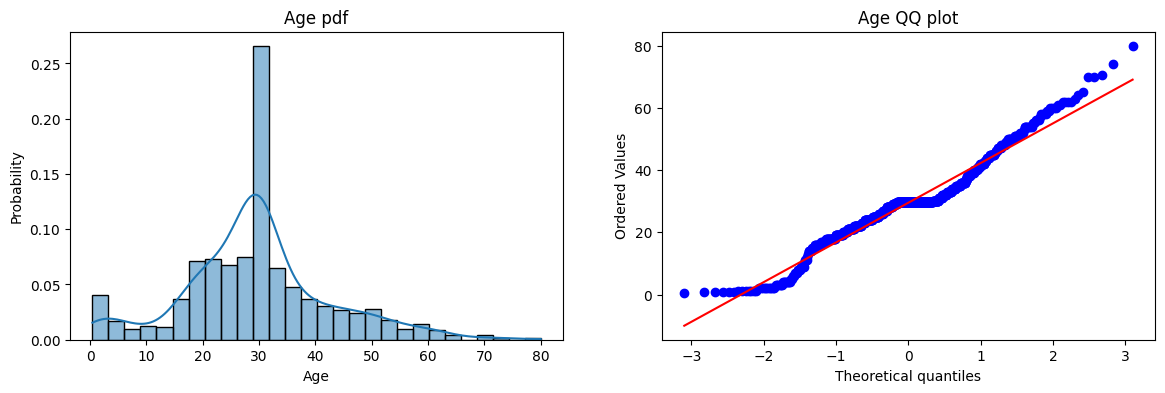

In [49]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Age'],kde=True,stat='probability')
plt.title('Age pdf')

plt.subplot(122)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age QQ plot')

plt.show()

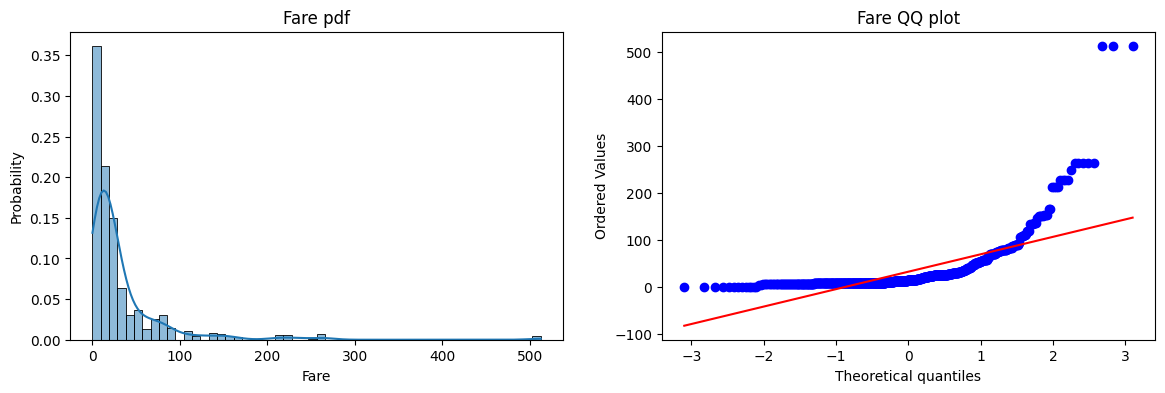

In [50]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(X_train['Fare'],kde=True,stat='probability')
plt.title('Fare pdf')

plt.subplot(122)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare QQ plot')

plt.show()

In [51]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [52]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_prad = clf.predict(X_test)
y_prad2 = clf2.predict(X_test)

print("accuracy LR ",accuracy_score(y_test,y_prad))
print("accuracy DT ",accuracy_score(y_test,y_prad2))

accuracy LR  0.6480446927374302
accuracy DT  0.6703910614525139


In [53]:
trf = FunctionTransformer(func=np.log1p)
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [54]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_prad = clf.predict(X_test_transformed)
y_prad1 = clf2.predict(X_test_transformed)

print("accuracy LR ",accuracy_score(y_test,y_prad))
print("accuracy DT ",accuracy_score(y_test,y_prad1))

accuracy LR  0.6815642458100558
accuracy DT  0.6759776536312849


In [55]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,Y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,Y,scoring='accuracy',cv=10)))


LR 0.678027465667915
DT 0.6644694132334582


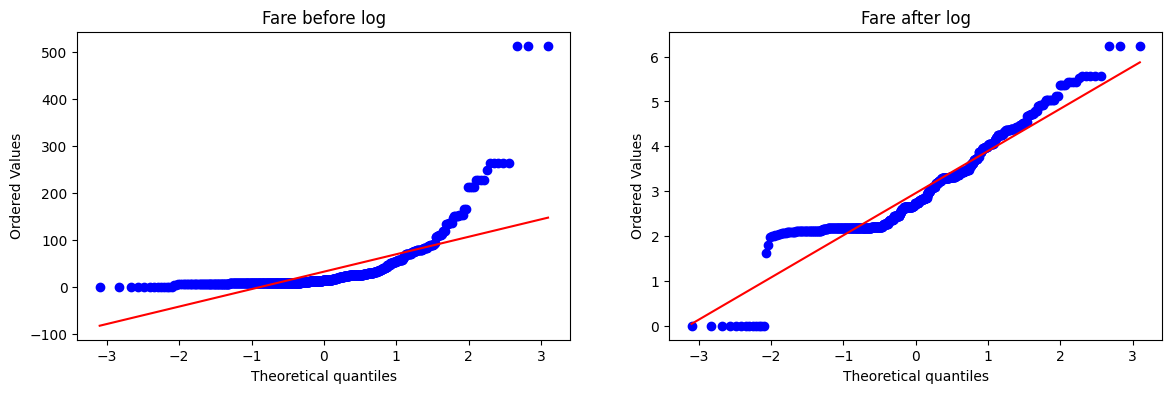

In [56]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Fare'],dist='norm',plot=plt)
plt.title('Fare before log')

plt.subplot(122)
stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('Fare after log')

plt.show()

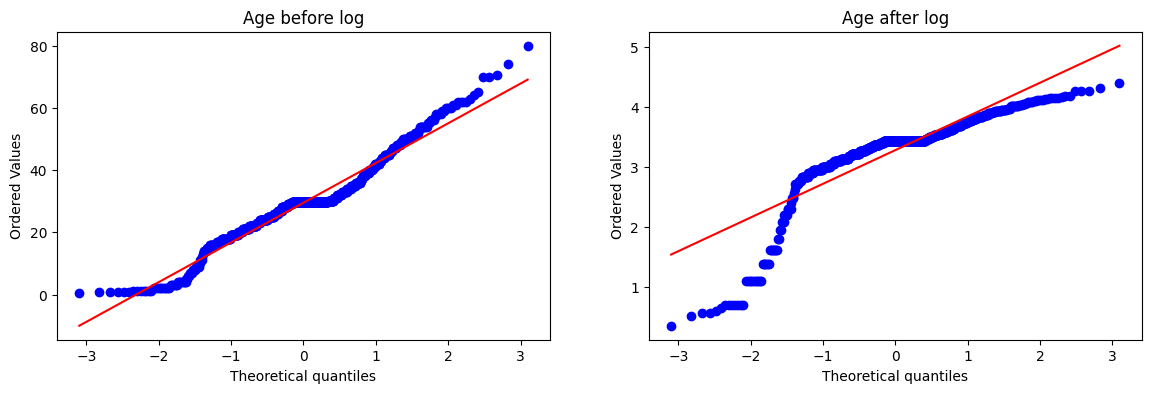

In [57]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(X_train['Age'],dist='norm',plot=plt)
plt.title('Age before log')

plt.subplot(122)
stats.probplot(X_train_transformed['Age'],dist='norm',plot=plt)
plt.title('Age after log')

plt.show()

In [58]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)

print("LR",accuracy_score(y_test,y_pred))
print("DT",accuracy_score(y_test,y_pred2))

LR 0.6703910614525139
DT 0.664804469273743


In [59]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,Y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,Y,scoring='accuracy',cv=10)))


LR 0.6712609238451936
DT 0.6621847690387017


In [60]:
def apply_transform(transform):
    X = df.iloc[: ,1:3]
    y = df.iloc[: ,0]

    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')

    X_trans = trf.fit_transform(X)

    clf = LogisticRegression()
    print("accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X_train['Fare'],dist='norm',plot=plt)
    plt.title('Fare before log')

    plt.subplot(122)
    stats.probplot(X_train_transformed['Fare'],dist='norm',plot=plt)
    plt.title('Fare after log')

    plt.show()
    

accuracy 0.6589013732833957


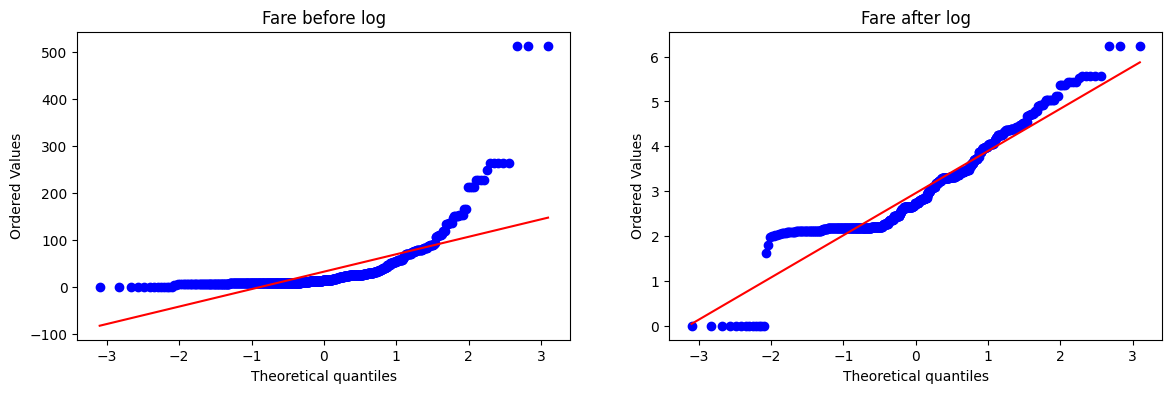

In [61]:
apply_transform(lambda x: x)

accuracy 0.6431335830212235


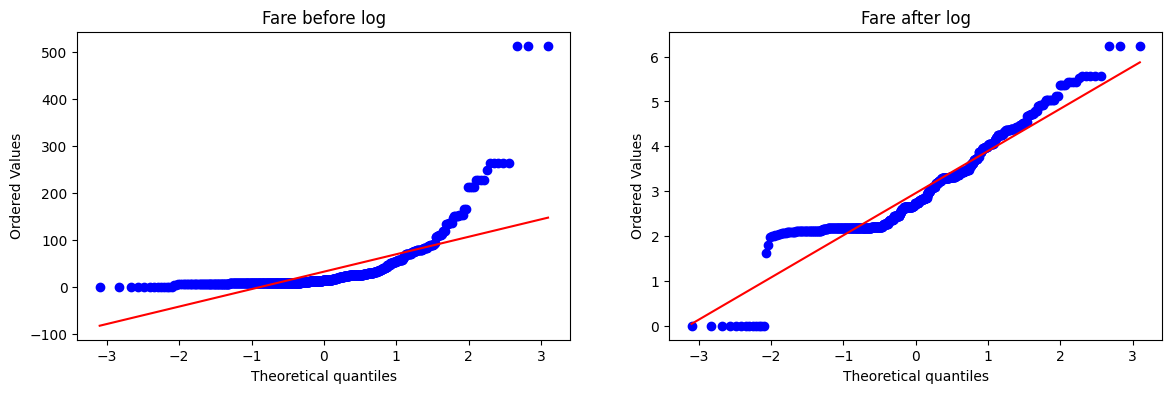

In [64]:
apply_transform(lambda x : x**2)

accuracy 0.6611485642946316


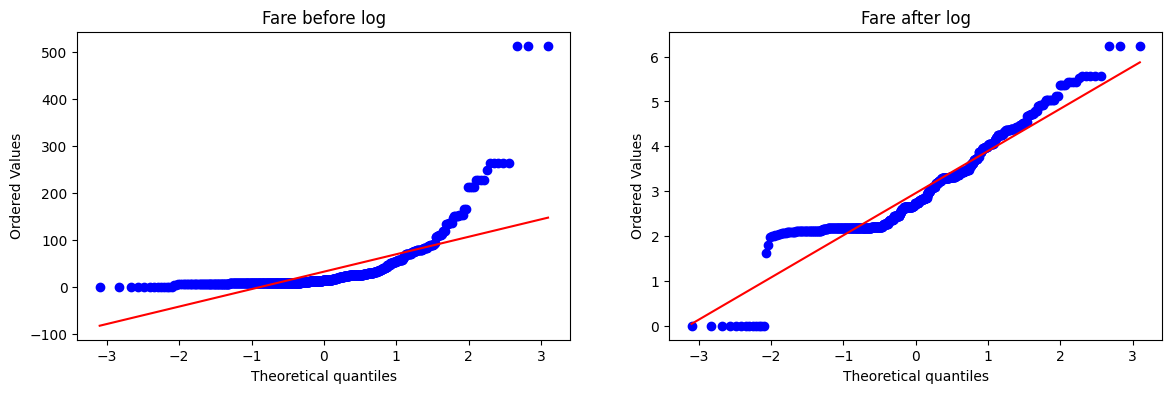

In [65]:
apply_transform(lambda x : x**0.5)

accuracy 0.61729088639201


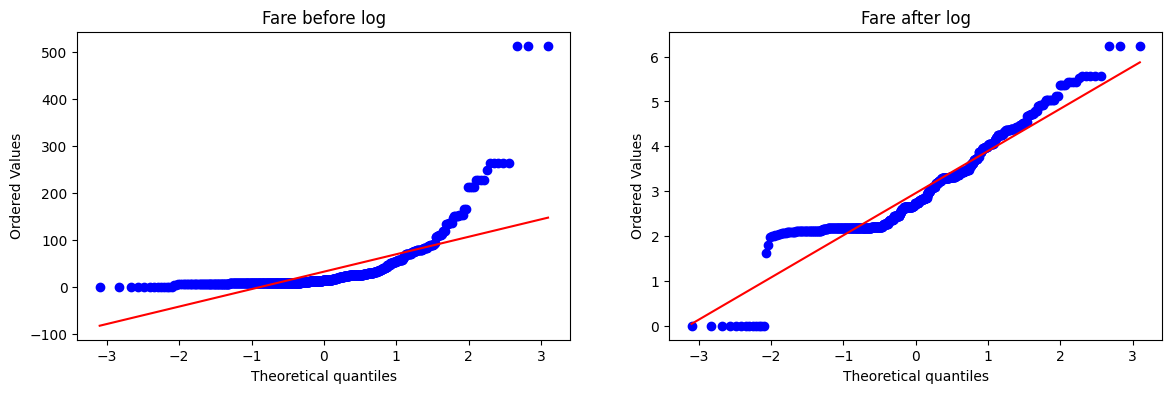

In [68]:
apply_transform(lambda x: 1/(x+0.000000000001))